✅ Mall Customers Dataset Loaded Successfully!
Data Dimensions: 200 shoppers, 5 structural metrics.

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Feature Statistical Summary ---
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%

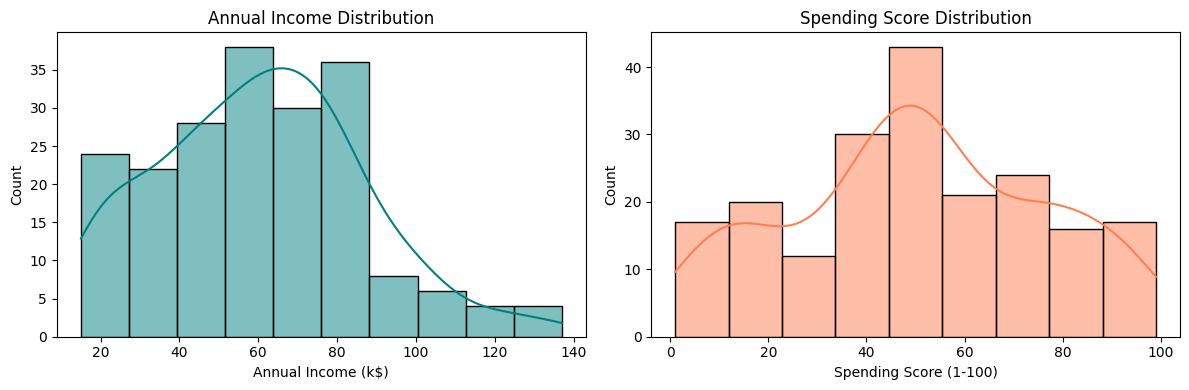

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# STEP 1: FETCH DATASET & CONDUCT EDA (UPDATED STABLE URL)
# Streaming from an active, stable public data repository
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

print("✅ Mall Customers Dataset Loaded Successfully!")
print(f"Data Dimensions: {df.shape[0]} shoppers, {df.shape[1]} structural metrics.\n")
print(df.head())

# Quick statistical verification for EDA
print("\n--- Feature Statistical Summary ---")
print(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe())

# Visualizing distributions for EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

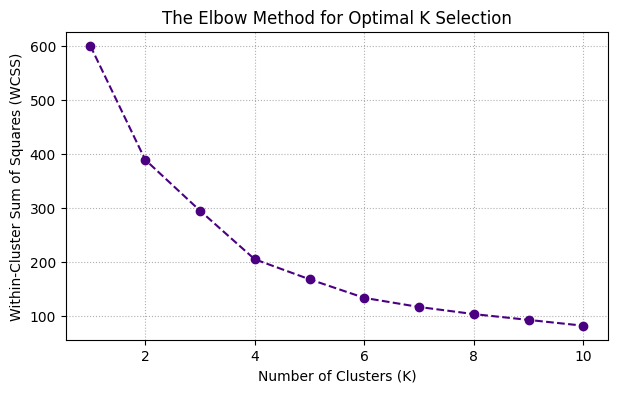

In [3]:
# STEP 2: DATA STANDARDIZATION & THE ELBOW METHOD
# =====================================================================
# Isolate numeric features relevant for behavioral grouping
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_raw = df[features]

# K-Means calculates geometric distances. We MUST scale data so 
# income scales don't overpower spending scores mathematically.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Calculate WCSS for cluster options 1 through 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='indigo')
plt.title('The Elbow Method for Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle=':')
plt.show()

In [4]:
# STEP 3: APPLY FINAL K-MEANS CLUSTERING
# =====================================================================
# Based on the empirical elbow joint of this dataset, K=5 is optimal.
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Calculate group center attributes to build business strategies
cluster_profiles = df.groupby('Cluster')[features].mean()
print("          MATHEMATICAL CLUSTER PROFILES           ")
print(cluster_profiles)

          MATHEMATICAL CLUSTER PROFILES           
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


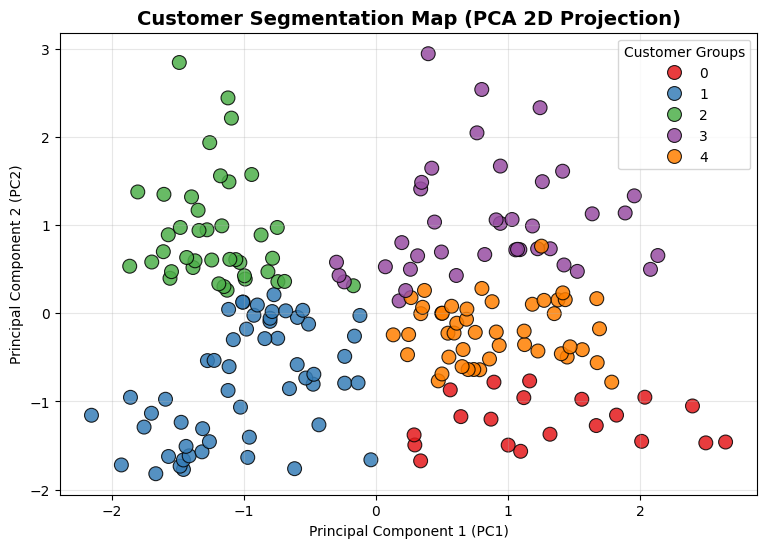

In [5]:
# STEP 4: DIMENSIONALITY REDUCTION (PCA) & VISUALIZATION
# Squash our 3D scaled feature matrix down to a 2D map coordinates
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Plot the engineered behavioral clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    palette='Set1', 
    data=df, 
    s=100, 
    edgecolor='black', 
    alpha=0.85
)
plt.title('Customer Segmentation Map (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Customer Groups', loc='best')
plt.grid(True, alpha=0.3)
plt.show()